In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
old_df = pd.read_csv(r"C:\data\고령인구비율_시도_시_군_구__20260616183149.csv", encoding='cp949')
alone_df = pd.read_csv(r"C:\data\독거노인가구비율_시도_시_군_구__20260616181852.csv", encoding='cp949')

print("고령인구비율:", old_df.shape)
print("독거노인가구비율:", alone_df.shape)

고령인구비율: (19, 361)
독거노인가구비율: (19, 31)


In [5]:
print("=== 고령인구비율 ===")
print(old_df .info)
print("=== 독거노인가구비율 ===")
print(alone_df.info)

=== 고령인구비율 ===
<bound method DataFrame.info of     행정구역별(1)                  2015.01           2015.01.1        2015.01.2  \
0   행정구역별(1)  고령인구비율<br>(A÷B×100) (%)  65세이상인구<br>(A) (명)  전체인구<br>(B) (명)   
1         전국                     12.8             6549277         51342881   
2      서울특별시                     12.1             1223221         10104515   
3      부산광역시                     14.1              494664          3517898   
4      대구광역시                     12.2              305141          2492658   
5      인천광역시                     10.3              299529          2904876   
6      광주광역시                     10.9              160620          1476891   
7      대전광역시                     10.4              159199          1531287   
8      울산광역시                      8.4               97922          1167232   
9    세종특별자치시                     12.4               19985           161716   
10       경기도                     10.2             1260611         12366711   
11   강원특별자치도     

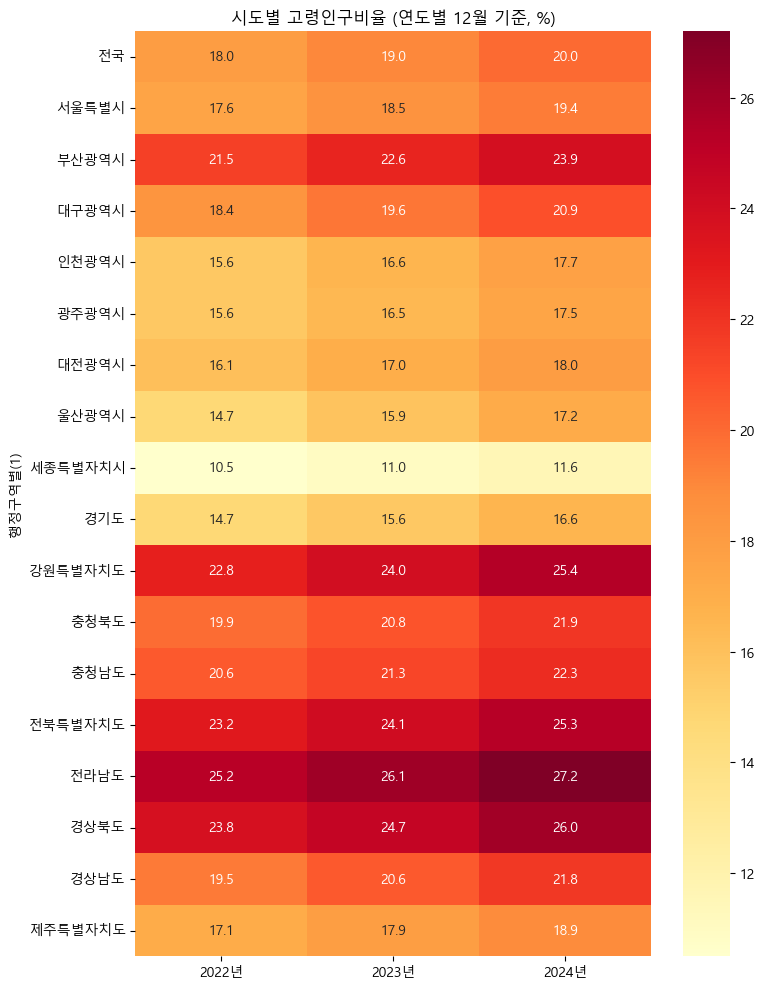

In [6]:
old_clean = old_df.iloc[1:].reset_index(drop=True)

dec_cols = ['2022.12', '2023.12', '2024.12']
heatmap_data = old_clean.set_index('행정구역별(1)')[dec_cols].astype(float)
heatmap_data.columns = ['2022년', '2023년', '2024년']

plt.figure(figsize=(8, 10))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('시도별 고령인구비율 (연도별 12월 기준, %)')
plt.tight_layout()
plt.show()

In [11]:
national_old = old_df.iloc[1:][old_df.iloc[1:]['행정구역별(1)'] == '전국']
dec_cols = [col for col in old_df.columns if col.endswith('.12')]
old_series = national_old[dec_cols].values[0].astype(float)

national_alone = alone_df[alone_df['행정구역별'] == '전국']
year_cols_alone = alone_df.columns[1::3]
alone_series = national_alone[year_cols_alone].values[0].astype(float)

compare_df = pd.DataFrame({
    '연도': list(range(2015, 2025)),
    '고령인구비율': old_series,
    '독거노인가구비율': alone_series
})

compare_df['연도'] = compare_df['연도'].astype(int)

print(compare_df)

     연도  고령인구비율  독거노인가구비율
0  2015    13.1       6.4
1  2016    13.5       6.7
2  2017    14.2       7.0
3  2018    14.8       7.2
4  2019    15.5       7.5
5  2020    16.4       7.9
6  2021    17.1       8.5
7  2022    18.0       9.1
8  2023    19.0       9.7
9  2024    20.0      10.3


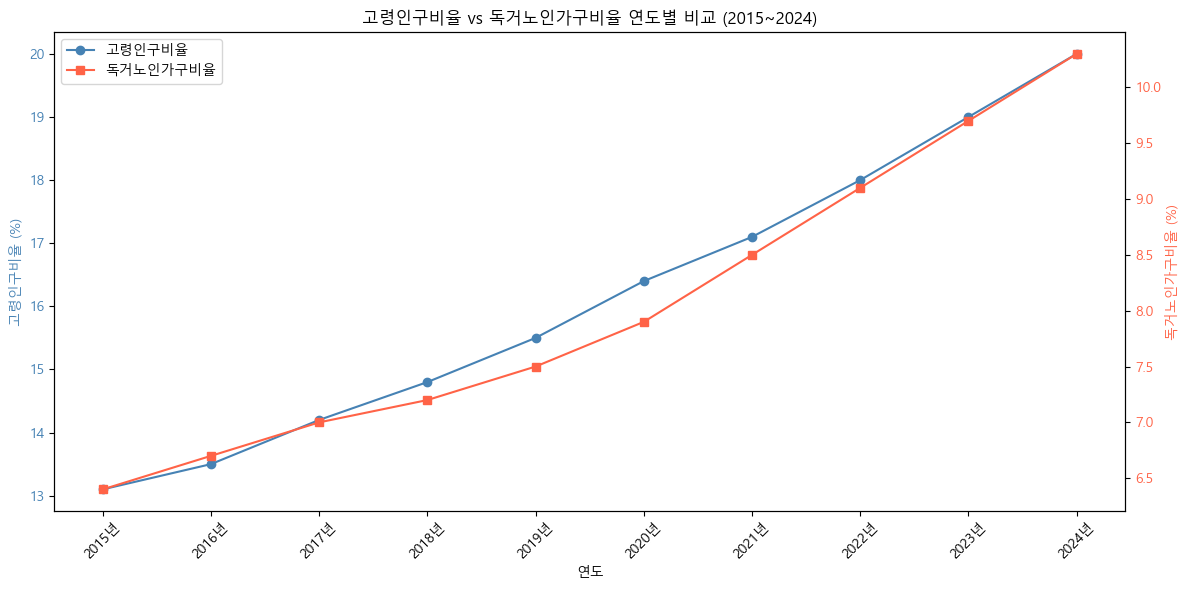

In [26]:
national_old = old_df.iloc[1:][old_df.iloc[1:]['행정구역별(1)'] == '전국']
national_alone = alone_df[alone_df['행정구역별'] == '전국']

dec_cols = [col for col in old_df.columns if col.endswith('.12')]
old_series = national_old[dec_cols].values[0].astype(float)

year_cols_alone = alone_df.columns[1::3]
alone_series = national_alone[year_cols_alone].values[0].astype(float)

years = list(range(2015, 2025))

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(years, old_series, color='steelblue', marker='o', label='고령인구비율')
ax1.set_xlabel('연도')
ax1.set_ylabel('고령인구비율 (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(years, alone_series, color='tomato', marker='s', label='독거노인가구비율')
ax2.set_ylabel('독거노인가구비율 (%)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

ax1.set_xticks(years)
ax1.set_xticklabels([f'{y}년' for y in years], rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('고령인구비율 vs 독거노인가구비율 연도별 비교 (2015~2024)')
plt.tight_layout()
plt.show()

In [22]:
old_sido = old_df.iloc[1:][['행정구역별(1)', '2024.12']].copy()
old_sido.columns = ['시도', '고령인구비율']
old_sido['고령인구비율'] = old_sido['고령인구비율'].astype(float)
old_sido = old_sido[old_sido['시도'] != '전국'].reset_index(drop=True)

alone_sido = alone_df.iloc[1:][['행정구역별', '2024']].copy()
alone_sido.columns = ['시도', '독거노인가구비율']
alone_sido['독거노인가구비율'] = alone_sido['독거노인가구비율'].astype(float)
alone_sido = alone_sido[alone_sido['시도'] != '전국'].reset_index(drop=True)

old_sido['시도'] = old_sido['시도'].str.replace('특별시', '').str.replace('광역시', '').str.replace('특별자치시', '').str.replace('특별자치도', '').str.replace('도', '').str.strip()
alone_sido['시도'] = alone_sido['시도'].str.replace('특별시', '').str.replace('광역시', '').str.replace('특별자치시', '').str.replace('특별자치도', '').str.replace('도', '').str.strip()

sido_compare_df = pd.merge(old_sido, alone_sido, on='시도')
sido_compare_df = sido_compare_df.sort_values('고령인구비율', ascending=True).reset_index(drop=True)

print(sido_compare_df)

     시도  고령인구비율  독거노인가구비율
0    세종    11.6       5.2
1    경기    16.6       7.9
2    울산    17.2       8.7
3    광주    17.5       9.5
4    인천    17.7       8.8
5    대전    18.0       8.8
6    제주    18.9       9.0
7    서울    19.4       8.6
8    대구    20.9      11.3
9   경상남    21.8      12.6
10  충청북    21.9      11.6
11  충청남    22.3      11.6
12   부산    23.9      12.7
13   전북    25.3      14.1
14   강원    25.4      13.9
15  경상북    26.0      14.3
16  전라남    27.2      16.1


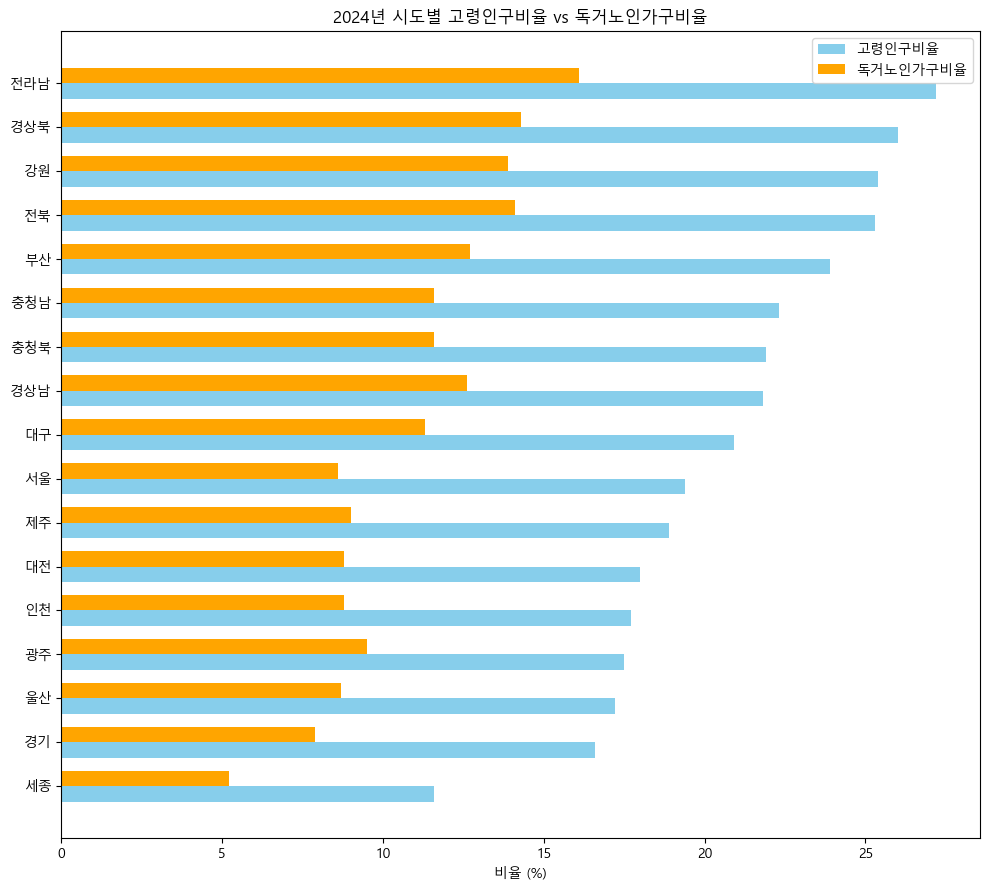

In [24]:
import numpy as np

x = np.arange(len(sido_compare_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 9))

bars1 = ax.barh(x - width/2, sido_compare_df['고령인구비율'], width, label='고령인구비율', color='skyblue')
bars2 = ax.barh(x + width/2, sido_compare_df['독거노인가구비율'], width, label='독거노인가구비율', color='orange')

ax.set_yticks(x)
ax.set_yticklabels(sido_compare_df['시도'])
ax.set_xlabel('비율 (%)')
ax.set_title('2024년 시도별 고령인구비율 vs 독거노인가구비율')
ax.legend()

plt.tight_layout()
plt.show()

In [17]:
import folium

sido_coords = {
    '서울':   (37.5665, 126.9780),
    '부산':   (35.1796, 129.0756),
    '대구':   (35.8714, 128.6014),
    '인천':   (37.4563, 126.7052),
    '광주':   (35.1595, 126.8526),
    '대전':   (36.3504, 127.3845),
    '울산':   (35.5384, 129.3114),
    '세종':   (36.4800, 127.2890),
    '경기':   (37.4138, 127.5183),
    '강원':   (37.8228, 128.1555),
    '충북':   (36.8000, 127.7000),
    '충남':   (36.5184, 126.8000),
    '전북':   (35.7175, 127.1530),
    '전남':   (34.8679, 126.9910),
    '경북':   (36.4919, 128.8889),
    '경남':   (35.4606, 128.2132),
    '제주':   (33.4996, 126.5312),
}

# 지도 생성
korea_map = folium.Map(location=[36.5, 127.5], zoom_start=7)

# 시도별 원 추가
for _, row in sido_compare_df.iterrows():
    sido = row['시도']
    if sido in sido_coords:
        lat, lon = sido_coords[sido]
        folium.CircleMarker(
            location=[lat, lon],
            radius=row['독거노인가구비율'] * 2,
            color='tomato',
            fill=True,
            fill_opacity=0.6,
            popup=f"{sido}: {row['독거노인가구비율']}%"
        ).add_to(korea_map)

korea_map

In [18]:
prophet_old = pd.DataFrame({
    'ds': pd.to_datetime(compare_df['연도'], format='%Y'),
    'y': compare_df['고령인구비율']
})

m1 = Prophet()
m1.fit(prophet_old)

prophet_alone = pd.DataFrame({
    'ds': pd.to_datetime(compare_df['연도'], format='%Y'),
    'y': compare_df['독거노인가구비율']
})

m2 = Prophet()
m2.fit(prophet_alone)

print("학습 완료!")

19:17:45 - cmdstanpy - INFO - Chain [1] start processing
19:17:53 - cmdstanpy - INFO - Chain [1] done processing
19:17:53 - cmdstanpy - INFO - Chain [1] start processing
19:18:02 - cmdstanpy - INFO - Chain [1] done processing


학습 완료!


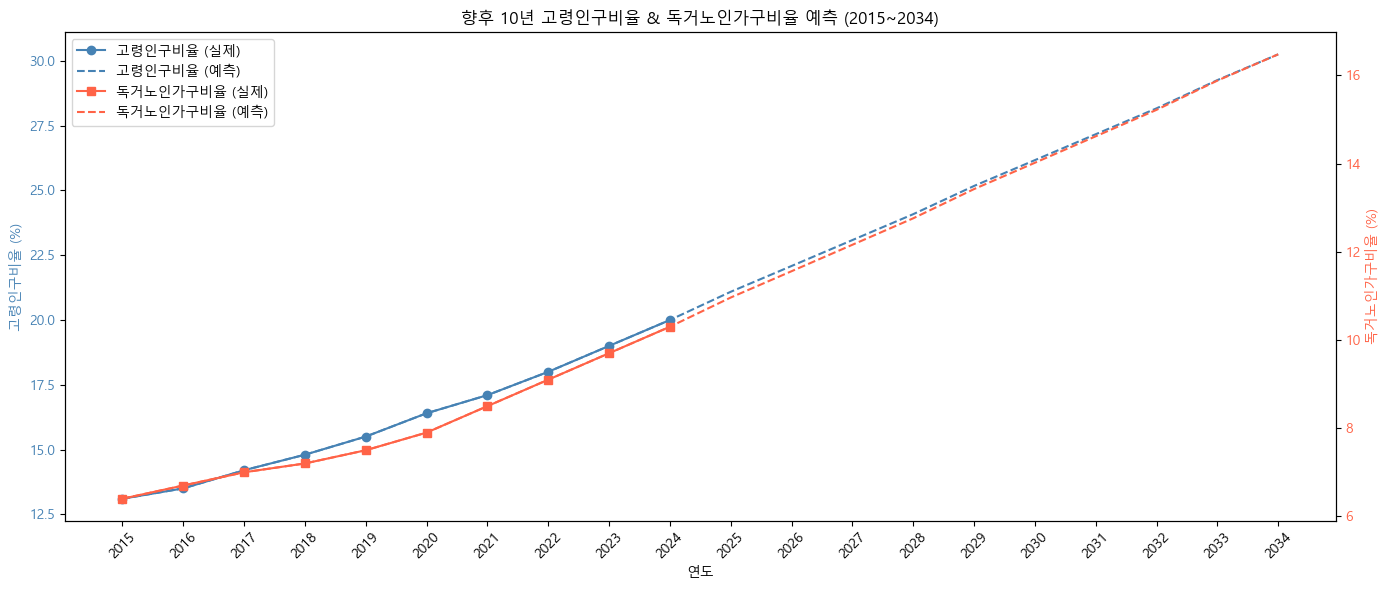

2034년 예측 고령인구비율: 30.3%
2034년 예측 독거노인가구비율: 16.5%


In [19]:
future = m1.make_future_dataframe(periods=10, freq='YS')
forecast1 = m1.predict(future)
forecast2 = m2.predict(future)

actual_years = compare_df['연도'].tolist()
pred_years = [d.year for d in forecast1['ds']]

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(actual_years, compare_df['고령인구비율'],
         color='steelblue', marker='o', label='고령인구비율 (실제)')
ax1.plot(pred_years, forecast1['yhat'],
         color='steelblue', linestyle='--', label='고령인구비율 (예측)')
ax1.set_xlabel('연도')
ax1.set_ylabel('고령인구비율 (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(actual_years, compare_df['독거노인가구비율'],
         color='tomato', marker='s', label='독거노인가구비율 (실제)')
ax2.plot(pred_years, forecast2['yhat'],
         color='tomato', linestyle='--', label='독거노인가구비율 (예측)')
ax2.set_ylabel('독거노인가구비율 (%)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

ax1.set_xticks(pred_years)
ax1.set_xticklabels([str(y) for y in pred_years], rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('향후 10년 고령인구비율 & 독거노인가구비율 예측 (2015~2034)')
plt.tight_layout()
plt.show()

# 2034년 예측값 출력
print(f"2034년 예측 고령인구비율: {forecast1['yhat'].iloc[-1]:.1f}%")
print(f"2034년 예측 독거노인가구비율: {forecast2['yhat'].iloc[-1]:.1f}%")